Accuracy : 0.956140350877193
Precision: 0.9459459459459459
Recall   : 0.9859154929577465
F1 Score : 0.9655172413793104
ROC-AUC  : 0.9977071732721913

Confusion Matrix:

[[39  4]
 [ 1 70]]


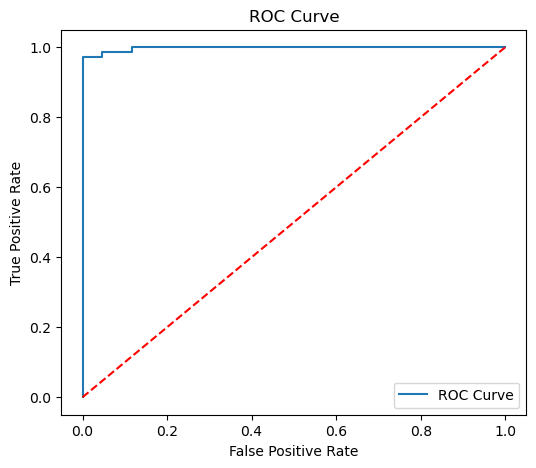


Results with Threshold = 0.3
Accuracy : 0.956140350877193
Precision: 0.9459459459459459
Recall   : 0.9859154929577465
F1 Score : 0.9655172413793104

Business Threshold Recommendation:
Threshold = 0.30 increases Recall, reducing False Negatives.
Useful when missing a positive case is more costly (e.g., disease detection, fraud detection).
Threshold = 0.50 provides a balanced trade-off.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Load Dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Class Probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Default Threshold = 0.5
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Example: Change Threshold Based on Business Cost
new_threshold = 0.30
y_pred_new = (y_prob >= new_threshold).astype(int)

print("\nResults with Threshold =", new_threshold)
print("Accuracy :", accuracy_score(y_test, y_pred_new))
print("Precision:", precision_score(y_test, y_pred_new))
print("Recall   :", recall_score(y_test, y_pred_new))
print("F1 Score :", f1_score(y_test, y_pred_new))

# Recommendation
print("\nBusiness Threshold Recommendation:")
print("Threshold = 0.30 increases Recall, reducing False Negatives.")
print("Useful when missing a positive case is more costly (e.g., disease detection, fraud detection).")
print("Threshold = 0.50 provides a balanced trade-off.")